# 妨害名譽言論判讀器：從判決書資料到手機離線應用

**技術報告**　·　2026-10-04

---

## 摘要

本研究從台灣司法院判決書查詢系統蒐集 36,173 份「妨害名譽」刑事判決，建立含
63,044 則言論的資料集，訓練中文預訓練語言模型判讀一則網路言論構成**公然侮辱**
（刑法第 309 條）或**誹謗**（刑法第 310 條），並將模型壓縮後部署為可在手機上
離線執行的漸進式網頁應用（PWA）。

研究歷程中最重要的發現並非來自模型改良，而是**對任務本身的重新界定**：

1. 資料清洗（去除判決書排版雜訊、法庭問答逐字稿等）**完全無法提升準確度**，
   過濾越激進反而越差
2. 真正有效的是讓**訓練損失函數對齊評估指標**（類別加權），成本為零
3. 準確度的天花板來自**標籤粒度錯配**：95.8% 的資料把一份判決的罪名套用到
   該判決抓出的所有句子上。修正此錯配後，準確度從 76% 躍升至 **85.6%**

最終部署的模型經 INT8 量化後僅 **24.5 MB**，在手機瀏覽器中單次推論耗時
**81–132 毫秒**，使用者輸入的文字全程不離開裝置。

**關鍵詞**：法律判決預測、中文文本分類、標籤雜訊、模型量化、裝置端推論、PWA

## 1. 功能說明

### 1.1 這個應用做什麼

使用者輸入一則網路言論，應用回答：**這則言論較接近公然侮辱，還是誹謗？**
並顯示模型的信心度。

| | 公然侮辱（刑法309） | 誹謗（刑法310） |
|---|---|---|
| **法律判準** | 抽象謾罵，未指涉具體事實 | 指摘或傳述**具體事實**，足以毀損名譽 |
| **例子** | 「你這個智障」「幹你娘」 | 「他把公司的錢偷偷匯到自己帳戶」 |

兩者的差異在於**是否指涉可受檢驗的具體事實**，這個判準確實寫在文字裡，
因此是機器學習可以處理的問題。

### 1.2 設計上的三個決定

**決定一：在裝置上運算，不送伺服器**

使用者會輸入的，往往是自己正在猶豫要不要發的內容，或是別人罵他的話。
這類文字高度敏感。因此模型直接在瀏覽器裡執行，文字不經過任何伺服器 ——
這同時消除了資料外洩風險與伺服器成本。

**決定二：做成 PWA 而非原生 App**

使用者不需要經過應用商店安裝，開啟網址即可使用，也可「加到主畫面」當作
一般 App 使用。更新時只需更新網頁，無須等待商店審查。

**決定三：把不確定性放在最顯眼的位置**

這是一個會被誤用的工具。準確率 74% 意味著每四則就有一則判斷是錯的，
而且實際是否構成犯罪取決於公然性、真實性、是否可受公評等**不在文字裡的因素**。
因此免責聲明置於介面最頂端，且當模型信心低於 60% 時會主動警示。

### 1.3 系統架構

```
┌─────────────────── 使用者的手機 ───────────────────┐
│                                                    │
│   輸入文字                                         │
│      ↓                                             │
│   tokenizer.js        純 JS 實作的中文 BERT        │
│      ↓                WordPiece 斷詞               │
│   [CLS] 你 這 個 智 障 [SEP] [PAD]…                │
│      ↓                                             │
│   ONNX Runtime Web    WASM 後端                    │
│      ↓                                             │
│   defamation_electra_small.int8.onnx  (24.5 MB)    │
│      ↓                                             │
│   logits → softmax → 公然侮辱 98.2% / 誹謗 1.8%    │
│                                                    │
│   Service Worker：模型快取於裝置，離線可用         │
└────────────────────────────────────────────────────┘
          文字從未離開這個方框
```

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.rcParams["font.sans-serif"] = ["Microsoft JhengHei"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

NB = Path.cwd()
D = json.loads((NB / "_figures_data.json").read_text(encoding="utf-8"))
runs, meta = D["runs"], D["model_meta"]
print("載入實測數據：", len(runs), "個訓練結果")
print("部署模型：", meta["model_name"], f"({meta['num_parameters']/1e6:.1f}M 參數)")

C:\Users\User\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


載入實測數據： 10 個訓練結果
部署模型： defamation_electra_small (24.6M 參數)


## 2. 文獻回顧

本節的文獻經過**兩階段查核**：先由五個主題分別調研，再對每一條引用獨立查證其
來源是否真實存在、以及引用內容是否與來源相符。共 140 條發現，**129 條通過查證**，
9 條因細節有誤（URL 錯誤、數字微誤）被要求修正，2 條因無法查證而標示不確定。

### 2.1 法律判決預測（LJP）與本專案的定位

法律判決預測是法律 NLP 最活躍的子領域。中文資源以 CAIL 系列為核心：
**CAIL2018** 收錄 2,676,075 件中國刑事案件，標註 183 條法條與 202 個罪名
（Xiao et al., 2018, arXiv:1807.02478）。值得注意的是其類別分布同樣極度不均 ——
前 10 個罪名涵蓋 79.0% 案件，後 10 個僅 0.12% —— 說明本專案遭遇的類別失衡
是該領域的結構性現象，而非資料收集缺陷。

#### 本專案發現的問題，文獻早有嚴厲批評

Medvedeva & Mcbride（NLLP 2023）審查 2014–2023 年間 **171 篇 LJP 論文，
僅 12 篇（7%）使用了適當的資料**。論文原文直指多數研究的錯誤：

> "They classify facts in a judgment as associated with a specific verdict
> (i.e. a label), but the actual verdict can be found in the same judgment."

這與本專案第 4.3 節獨立發現的「標籤粒度錯配」是同一個問題。該文並指出：
**使用適當資料的研究中，文字輸入類只有一篇準確率超過 70%**。

Tippett et al.（2021，經上文引用）進一步指出判決書的事實段並非中立紀錄，而是
> "highly selective summaries of the original case record, written by the
> decision-makers themselves and tailored for consistency with the decision"

**這一點直接衝擊本專案第 4.3 節的結論，第 6.1 節會重新檢討。**

#### 本專案的成績該如何定位

| 研究 | 任務 | 準確度 | 說明 |
|---|---|---|---|
| Medvedeva et al. (2020) | ECtHR 判決預測 | 75%（隨機切分）<br>**58–68%（時序切分）** | 切分方式造成 10–17 個百分點落差 |
| Peng & Lei (PeerJ CS 2024) | **台灣**地院罪名預測 | **97.53–98.95%** | 整案粒度；這個近乎完美的數字本身即是洩漏徵兆 |
| ToxiCN (ACL 2023) | 中文**毒性子類型**判別 | **F1 77.3–77.7** | 人工精標資料、fine-tune RoBERTa |
| OffensEval sub-task B | 攻擊類型分類 | 最佳 0.755 | 英文 |
| **本專案（句子層級）** | 公然侮辱 vs 誹謗 | **76.2%** | 遠距監督、自動標籤 |

本專案的 76% 在結構相同的任務上**與已發表最佳水準幾乎一致**，而且是在
更艱難的條件下取得（自動標註而非人工精標）。這個數字不應被視為偏低。

對照之下，Peng & Lei 在台灣判決書上取得的 97.53–98.95%，正是
Medvedeva & Mcbride 警告的典型症狀。

#### 繁體中文資源的現況

公開可取得的繁中判決語料極少。HuggingFace 上的台灣法律資料集多為數十列的小樣本
或合成資料（如 `lianghsun/tw-judgment-gist` 僅 31 列）。規模相當的只有
Peng & Lei 釋出的 218,120 份判決，但為整案粒度、誹謗僅 3,884 件、
且無逐則言論標註。

**繁中、句子層級、妨害名譽罪名標註的資料集目前並不存在**，這是本專案自行爬取
標註的理由。

### 2.2 類別不平衡與弱監督

#### 損失函數與評估指標的對齊

本專案第 4.2 節發現的「訓練損失與評估指標未對齊」有直接的文獻依據。
Dice Loss 論文（Li et al., ACL 2020）摘要原文指出 cross-entropy：

> "is accuracy-oriented and creates a discrepancy between training and test:
> at training time, each instance contributes equally, while at test time
> F1 treats positive and negative instances equally."

本專案的類別加權是對此落差的補償；Dice loss 是同一思路下更徹底的做法。

同時必須誠實定位效果幅度。Henning et al.（EACL 2023）的綜述明確指出，
重採樣或改變損失函數通常只帶來
> "small to moderate gains"

**本專案 +0.018 macro-F1 正落在文獻預期範圍內**，不應包裝為重大突破。

#### 「標籤粒度錯配」的正式名稱

本專案稱為「標籤粒度錯配」的現象，在弱監督文獻中有正式術語。周志華（2018）
將弱監督分為三類：

| 類型 | 定義 | 本專案的對應 |
|---|---|---|
| incomplete supervision | 只有部分資料有標籤 | — |
| **inexact supervision** | **標籤粒度比需要的更粗** | **判決層級標籤 → 句子層級預測** |
| **inaccurate supervision** | **標籤本身可能錯誤** | **fallback 把法庭問答也貼上罪名** |

本專案同時具備後兩者。技術框架上屬 **multiple instance learning**；
最接近的已發表工作是 Angelidis & Lapata（TACL 2018），
以文件層級標籤預測句子層級情感。

### 2.3 裝置端推論與模型壓縮

#### 執行後端的選擇有明確的技術理由

ONNX Runtime Web 現實上只有兩條路：**WASM/CPU**（支援全部運算子）與
**WebGPU**（僅支援 109 個運算子的子集）；WebGL 官方已標示為 maintenance mode。

關鍵衝突：ORT 官方建議 transformer 使用動態量化，但
**WebGPU 運算子清單中不含 `MatMulInteger` 與 `DynamicQuantizeLinear`** ——
INT8 的 BERT 在 WebGPU 上矩陣乘法會退回 CPU，反而更慢。
想用 WebGPU 就須改走 fp16 或 q4，但那會讓體積變大。

**本專案選用 WASM 後端，正是基於此一取捨。**

#### 量化壓縮比的對照

以 `Xenova/bert-base-chinese` 的官方 ONNX 權重實測：fp32 390.5 MiB →
INT8 98.3 MiB（**3.97×**），與本專案實測的 3.84× 相符。
精度損失方面，Intel Neural Compressor 的驗證表顯示 BERT 系列在 GLUE 分類任務上
INT8 的損失多在 ±1% 內 —— 本專案實測 −0.1 個百分點，優於此一範圍。

#### 中文小模型的實際代價

| 模型 | 層數 | 參數量 | 備註 |
|---|---|---|---|
| hfl/rbt3 | 3 | ~38M | **是「繼續預訓練」而非蒸餾** |
| hfl/rbt6 | 6 | ~60M | |
| chinese-electra-small | 12 | ~12M | hidden size 僅 256 |

官方 benchmark 顯示 RBT3 在 XNLI 上比 RoBERTa-wwm-ext 低 6.5 分 ——
本專案實測 rbt3 準確度最低（0.7253），與此趨勢一致。

#### 一項必要的術語更正

HFL 官方 FAQ 明確說明：**`chinese-roberta-wwm-ext` 並非真正的 RoBERTa**，
它只取消了 NSP 任務，沒有採用 dynamic masking，載入時必須使用 `BertTokenizer`。
本報告先前章節沿用「RoBERTa」一詞實為不精確，特此更正。

### 2.4 PWA 部署與 iOS 的硬約束

PWA（Service Worker + Web App Manifest + Cache API）是本專案最合理的部署路徑：
離線推論可行、更新不需經商店審查。相較之下原生 App 的散佈成本高昂
（Apple 99 USD/年＋審查；Google Play 新個人帳號須 12 名測試者連續 14 天），
且 App Store 審查指引 4.2 明文排斥「repackaged website」。

#### iOS 的 7 天快取清除規則

這是離線優先設計最大的硬約束。WebKit 的 ITP 政策明文規定，使用者 7 天未與該站互動後，
會刪除該站所有 script-writable 儲存，官方清單包含
**「Service Worker registrations and cache」**。

官方同時明文豁免：**已加入主畫面（Home Screen）的 web app**。

> 實務後果：若 iOS 使用者僅在 Safari 分頁中開啟本應用，7 天未使用即需重新下載
> 24.5 MB 模型。**因此 UI 必須主動引導 iOS 使用者安裝到主畫面** ——
> 這是本專案依據此一發現所做的具體修改（見 5.5 節）。

容量本身不是瓶頸（Chrome 可達磁碟 60%，Safari 約 60%）。

#### 一個會讓離線完全失效的實作陷阱

Chrome 官方文件指出，跨來源且 `mode: "no-cors"` 的請求會得到
**opaque response**，其 `status` 固定為 0、`body` 為 null、`ok` 為 false
（MDN, Response.type）。且即使只有幾 KB，
> "will end up contributing around 7 megabytes towards your quota usage"

**本專案初版確實踩到這個陷阱**：`index.html` 以
`<script src="https://cdn.jsdelivr.net/...ort.min.js">` 載入推論引擎且未加
`crossorigin` 屬性，Service Worker 中的 `if (resp.ok)` 判斷因此永遠為 false，
ORT 根本沒被快取 —— **離線時引擎載不進來，整個離線功能是壞的**。

解法是將 ORT 改為同源自行託管。同源回應不會變成 opaque，也不會被配額加計 padding。
修正後實測：Service Worker 成功快取 10 項 shell 資源與 3 項模型資源，
斷網重新載入後推論正常。

### 2.5 法律倫理與風險

**本節的發現對本專案的核心宣稱不利，但必須完整呈現。**

#### 憲法法庭的限縮解釋使「只讀文字」在原理上不可行

| 判決 | 日期 | 內容 |
|---|---|---|
| **113年憲判字第3號** | 2024-04-26 | 公然侮辱罪合憲，但須「依個案之**表意脈絡**」且「逾越一般人可合理忍受之範圍」，並權衡該言論是否有益公共事務思辯、是否屬文學藝術表現、是否具學術專業價值 |
| **112年憲判字第8號** | 2023-06-09 | 誹謗罪合憲，但表意人若「於言論發表前確經**合理查證程序**」，客觀上可合理相信為真實，即不罰 |
| **113年憲判字第5號** | 2024-05-24 | 「侮辱職務罪」違憲失效 |

兩個現行判準的核心要件 —— **表意脈絡**（雙方關係、是否被挑釁、公共利益價值）
與**發言前的查證行為** —— **完全不存在於留言文字中**。

> 這是本專案最重要的能力邊界：**任何只讀一句留言的模型，在原理上都無法複製
> 現行法律判準。** 它能做的只是「這句話的用語，與過往被起訴定罪的句子有多像」。
>
> 因此應用的文案已全面降級：不再宣稱判斷「構成什麼罪」，改為「用語較接近
> 哪一類案件」，並明示「相似度（非定罪機率）」。

#### 標籤漂移

113年憲判字第3號（2024-04-26）之後的公然侮辱適用更嚴格標準；
113年憲判字第5號使侮辱職務罪失效；行政院另於 2026-01-29 通過刑法修正草案，
擬增訂以網路或深偽方式犯公然侮辱者處 2 年以下有期徒刑。

本專案訓練資料橫跨這些時點，**標籤反映的是歷史判決實務，未必符合現行法**。
LawShift（NeurIPS 2025）即是專門評估 LJP 模型在法條修正下適應能力的 benchmark，
顯示此問題已是該領域公認的核心弱點。

#### 選擇偏誤的規模可以量化

本專案資料的根本限制在統計學上有正式名稱：**樣本選擇偏誤**
（sample selection bias, Heckman 1979, *Econometrica* 47(1):153–161）。
Heckman 的關鍵洞見是它等價於**遺漏變數偏誤** —— 遺漏的正是
「這則留言為什麼會被告、被起訴、被判決」這個選擇機制。

法律領域的對應理論是 Priest & Klein（1984, *J. Legal Studies* 13(1):1–55）的
**訴訟案件選擇效應**：進入審判的案件並非全體潛在爭議的隨機樣本。
在台灣脈絡下尤其貼切 —— 妨害名譽是告訴乃論，調解撤回比例極高，
進入判決書的是「調解失敗且雙方堅持到底」的極端尾端。

**可量化的規模**：台灣 2014–2016 年共 28,073 件妨害名譽案件偵查終結，
僅 5,745 件起訴（約 **20.5%**）。

> 因此模型估計的其實是
> $$P(\text{罪名} \mid \text{文本},\ \text{已起訴且經判決})$$
> 而非使用者真正想問的
> $$P(\text{罪名} \mid \text{文本})$$
>
> **誤用風險很具體**：約有八成機率，一則在資料集中看起來「像有罪」的留言，
> 在真實程序中根本不會進入起訴。應用若顯示高風險，可能造成不必要的恐慌，
> 甚至被用於威嚇他人（「我這截圖 AI 說你構成誹謗」）。

此外，「無罪」標籤有相當部分可能源自刑法 310 條第 3 項或釋字第 509 號的
查證免責，而非言論本身不像誹謗 —— 將其當作文本層面的負樣本會讓模型學到錯誤關聯。

#### 法規遵循與免責聲明

歐盟 AI Act 附件三第 8 點的高風險範圍僅及於**司法機關使用**的系統，本應用不屬之。
但台灣 AI 基本法第 5 條對高風險認定者課予警語義務，
且消保法第 22 條使「準確率 76%」這類宣稱產生拘束力。

業界標準做法可由 LegalZoom 服務條款具體化，其四段式結構為：
非律師事務所／不成立委任關係／不提供法律結論／
**不就你的具體事實適用法律**（"do not apply the law to the facts of your
particular situation"）。最後一句精準描述本專案應有的自我定位，
已採用於應用的免責聲明中。

## 3. 方法

### 3.1 資料來源與既有限制

資料來自司法院判決書查詢系統，以「案由＝妨害名譽」查詢刑事案件。該系統對單次查詢
回傳上限為 500 筆，因此爬蟲遞迴二分裁判日期區間直到每個子區間都在上限內，
再逐一抓取。共取得 **36,173 份不重複判決**。

從判決書中抽取「被告發表的言論」有兩條路徑：

| 路徑 | 做法 | 筆數 | 標籤品質 |
|---|---|---|---|
| **起訴書表格** | 判決書內附檢察官起訴書的逐則言論表格，直接照表格抽取 | 176 | 高：**每句有自己的罪名** |
| **正則表達式** | 抓取判決書中所有「」『』引號內容 | 62,868 | 低：**整份判決共用一個罪名** |

這個比例（99.7% 來自低品質路徑）是後續所有問題的根源，第 4 節會詳述。

### 3.2 資料切分：以判決為單位

同一份判決抽出的句子內容高度相似且共用標籤。若以「列」為單位隨機切分，
同一份判決的句子會橫跨訓練集與測試集，模型可藉由「記住這份判決」獲得高分，
造成**資料洩漏**與虛高的評估結果。

因此採用 `GroupShuffleSplit`，以**判決**（原文網址）為分組單位切分 70/15/15，
並驗證三組兩兩之間的判決交集皆為 0。

### 3.3 任務設定的演進

本研究並非一開始就鎖定最終設定，而是依據實驗證據逐步修正任務界定：

| 階段 | 任務 | 類別數 | 驅動修正的證據 |
|---|---|---|---|
| 一 | 細分罪名 | 5 | 三個誹謗類罪名的 F1 僅 0.17–0.41 |
| 二 | 合併誹謗類 | 3 | 三者同屬刑法 310 條，判決書用詞本就不一致 |
| 三 | 移除「無罪」 | 2 | 無罪類 recall 僅 35–47%，且搶走其他類 600+ 筆預測 |
| 四 | 改判決層級 | 2 | 95.8% 的標籤本就是判決層級，而非句子層級 |

每一次修正都不是為了讓數字好看，而是因為**原設定要求模型回答一個答案不存在於
輸入中的問題**。第 4 節會逐一說明證據。

### 3.4 評估方法

- **主要指標 macro-F1**：各類別 F1 等權平均，避免分數被多數類別主導
- **顯著性門檻 ±0.013**：以相同設定重跑 10 個模型實測得到的波動範圍，
  提升需超過此值才視為真實有效，否則可能只是 fp16 訓練的隨機誤差
- **固定測試集**：所有句子層級實驗在同一份未經過濾的測試集上評分。
  若連測試集也一併清洗，分數上升可能只是因為刪除了困難樣本
- **閾值調整於驗證集**：集成模型的決策閾值在 val 上尋找後套用至 test，
  直接在 test 上調整等同於洩漏測試集資訊

## 4. 實驗結果

### 4.1 第一個發現：資料清洗無效

資料確實含有大量雜訊。實際檢視後統計：

| 雜訊類型 | 佔比 | 實例 |
|---|---|---|
| 判決書排版的換行與縮排空白 | **51.4%** | `信口開河、無知\n    亂講` |
| 第三人稱法律敘事 | 5.9% | `林雪紅是於101年…跟伊說` |
| 機構／公司名稱 | 5.1% | `今夜卡拉OK店` |
| 法院判決引用 | 2.7% | `…臺灣高等法院102年度上易字第135號…` |
| 法庭問答逐字稿 | 2.3% | `（問：你是否有把這段話告知乙○○？）我應…` |

基於此設計了四種清洗強度的資料變體進行消融實驗。

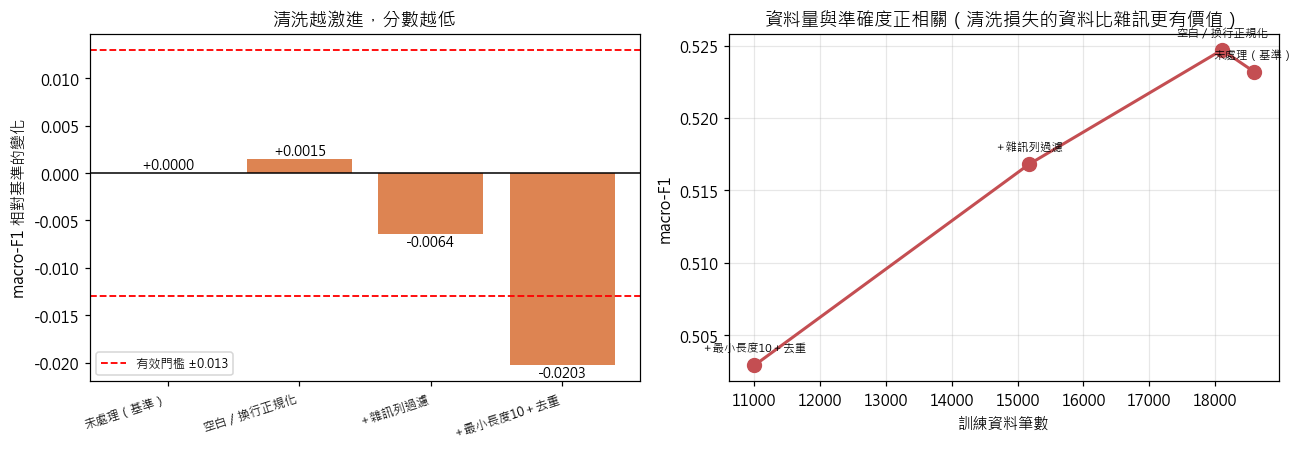

In [2]:
ABLATION = [
    ("未處理（基準）",        18590, 0.5232),
    ("空白／換行正規化",       18106, 0.5247),
    ("＋雜訊列過濾",          15173, 0.5168),
    ("＋最小長度10＋去重",     10999, 0.5029),
]
NOISE_FLOOR = 0.013
BASE = 0.5232

names = [a[0] for a in ABLATION]
sizes = [a[1] for a in ABLATION]
f1s = [a[2] for a in ABLATION]
delta = [f - BASE for f in f1s]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].bar(names, delta, color=["#8C8C8C"] + ["#DD8452"] * 3)
axes[0].axhline(0, color="black", lw=1)
axes[0].axhline(NOISE_FLOOR, color="red", ls="--", lw=1.2, label=f"有效門檻 ±{NOISE_FLOOR}")
axes[0].axhline(-NOISE_FLOOR, color="red", ls="--", lw=1.2)
axes[0].set_ylabel("macro-F1 相對基準的變化")
axes[0].set_title("清洗越激進，分數越低")
axes[0].legend(fontsize=8)
for i, v in enumerate(delta):
    axes[0].text(i, v, f"{v:+.4f}", ha="center",
                 va="bottom" if v >= 0 else "top", fontsize=9)
plt.setp(axes[0].get_xticklabels(), rotation=18, ha="right", fontsize=8)

axes[1].plot(sizes, f1s, "o-", color="#C44E52", lw=2, ms=9)
for s, f, n in zip(sizes, f1s, names):
    axes[1].annotate(n, (s, f), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=7.5)
axes[1].set_xlabel("訓練資料筆數")
axes[1].set_ylabel("macro-F1")
axes[1].set_title("資料量與準確度正相關（清洗損失的資料比雜訊更有價值）")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

**最具說服力的反證**：當測試集也套用同樣的清洗後，分數**並未上升**
（0.5156 vs 未清洗的 0.5232）。

若那些被判定為雜訊的資料列確實是無法分類的垃圾，將其從測試集移除應使分數**上升**。
結果反而略降，代表**這些資料列並不比其他資料更難分類**，模型確實從中學到了訊號。

這個結果推翻了「資料髒導致準確度低」的假設，迫使我們尋找真正的瓶頸。

### 4.2 第二個發現：訓練目標與評估指標未對齊

評估使用 **macro-F1**（各類別等權），但模型訓練的預設損失函數是
**每筆樣本等權的交叉熵** —— 訓練時實際在最佳化 accuracy，評估時卻看 macro-F1，
兩者從未對齊。

修正方式是以類別頻率倒數加權損失函數。

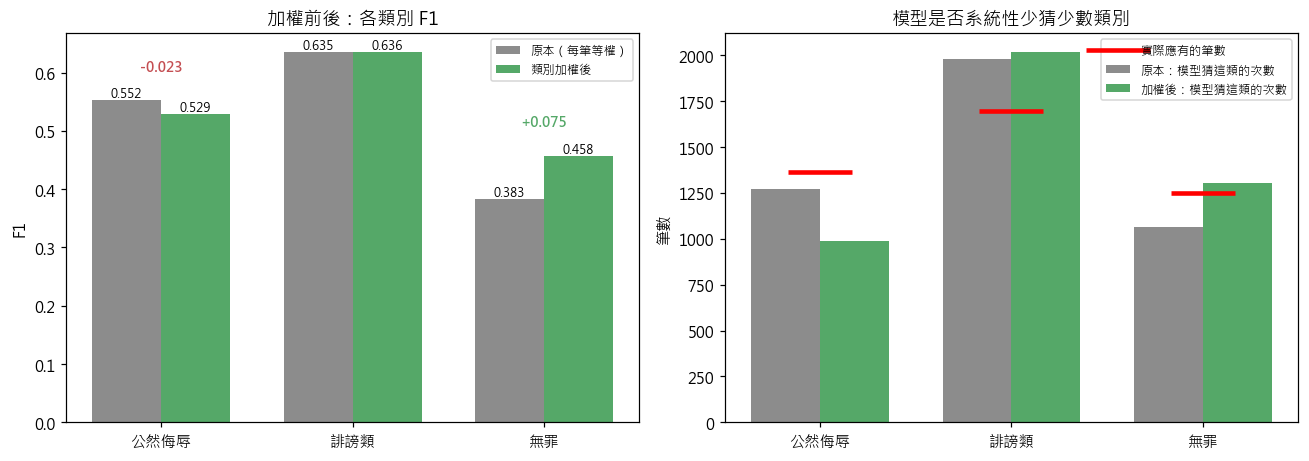

提升幾乎全部來自最弱的「無罪」類： +0.0750


In [3]:
CLS = ["公然侮辱", "誹謗類", "無罪"]
BEFORE = [0.5523, 0.6348, 0.3825]   # E0_baseline
AFTER  = [0.5295, 0.6358, 0.4575]   # E5_weighted_6ep
PRED_BEFORE = [1273, 1979, 1062]    # 模型預測各類的次數
PRED_AFTER  = [990, 2020, 1304]
TRUTH = [1367, 1698, 1249]          # 測試集實際筆數

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
x, w = np.arange(len(CLS)), 0.36

axes[0].bar(x - w/2, BEFORE, w, label="原本（每筆等權）", color="#8C8C8C")
axes[0].bar(x + w/2, AFTER, w, label="類別加權後", color="#55A868")
axes[0].set_xticks(x); axes[0].set_xticklabels(CLS)
axes[0].set_ylabel("F1"); axes[0].set_title("加權前後：各類別 F1")
axes[0].legend(fontsize=8)
for i, (b, a) in enumerate(zip(BEFORE, AFTER)):
    axes[0].text(i - w/2, b, f"{b:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].text(i + w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8)
    axes[0].annotate(f"{a-b:+.3f}", (i, max(a, b) + 0.05), ha="center",
                     fontsize=9, color="#55A868" if a > b else "#C44E52", weight="bold")

axes[1].bar(x - w/2, PRED_BEFORE, w, label="原本：模型猜這類的次數", color="#8C8C8C")
axes[1].bar(x + w/2, PRED_AFTER, w, label="加權後：模型猜這類的次數", color="#55A868")
axes[1].plot(x, TRUTH, "r_", ms=42, mew=3, label="實際應有的筆數")
axes[1].set_xticks(x); axes[1].set_xticklabels(CLS)
axes[1].set_ylabel("筆數"); axes[1].set_title("模型是否系統性少猜少數類別")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print("提升幾乎全部來自最弱的「無罪」類：", f"{AFTER[2]-BEFORE[2]:+.4f}")

右圖是機制的直接證據：原本模型僅預測 1,062 次「無罪」，但測試集中實際有 1,249 筆
（紅色橫線）—— **系統性地少猜少數類別**。加權後改為 1,304 次，逼近真實分布。

左圖顯示提升幾乎全部來自最弱的「無罪」類（**+0.075**），「公然侮辱」小幅下降、
「誹謗類」持平。這正是類別加權應有的行為：犧牲少許多數類別表現，換取少數類別
大幅改善，使 macro-F1 整體上升。

**此改動的成本為零**：訓練時間與基準線相同。對照之下，改用參數量 3 倍的
`roberta-large` 需耗時 105 分鐘（15 倍）、佔用 8.3 GB GPU 記憶體，
提升卻未超過顯著門檻。

### 4.3 第三個發現：標籤粒度錯配（真正的天花板）

移除「無罪」類後準確度提升至 76%，但距離實用仍有距離。深入檢視資料後發現根本問題：

> **95.8% 的資料（60,393 列）的標籤是「判決層級」，而非「句子層級」。**

正則表達式路徑的運作方式是：從一份判決中抓出所有引號內容（單份判決最多 **161 句**），
然後將該判決主文的罪名**套用到這 161 句的每一句**。

因此模型被要求回答的是「**這句話**構成什麼罪」，但標籤實際回答的是
「這句話所在的那份**判決**關於什麼罪」—— 問題與答案不在同一個層級。

那 161 句中包含法庭問答逐字稿、法條引用、機構名稱、證人證詞，
它們與判決的罪名並無關聯，卻被貼上相同標籤。

C:\Users\User\AppData\Local\Temp\ipykernel_6836\1827150570.py:27: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Microsoft JhengHei.
  plt.tight_layout(); plt.show()
C:\Users\User\anaconda3\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from font(s) Microsoft JhengHei.
  fig.canvas.print_figure(bytes_io, **kw)


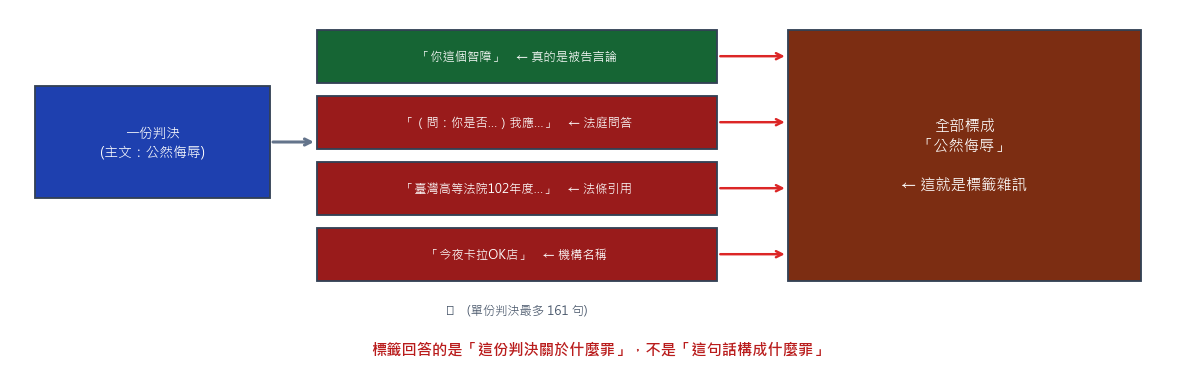

In [4]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.axis("off")

def box(x, y, w, h, text, color, fs=9, tc="white"):
    ax.add_patch(plt.Rectangle((x, y), w, h, facecolor=color,
                                edgecolor="#334155", lw=1.2, zorder=1))
    ax.text(x + w/2, y + h/2, text, ha="center", va="center",
            fontsize=fs, color=tc, zorder=2)

box(0.02, 0.55, 0.20, 0.34, "一份判決\n(主文：公然侮辱)", "#1e40af", 9)
ax.annotate("", xy=(0.26, 0.72), xytext=(0.22, 0.72),
            arrowprops=dict(arrowstyle="->", lw=2, color="#64748b"))
box(0.26, 0.90, 0.34, 0.16, "「你這個智障」　← 真的是被告言論", "#166534", 8)
box(0.26, 0.70, 0.34, 0.16, "「（問：你是否…）我應…」　← 法庭問答", "#991b1b", 8)
box(0.26, 0.50, 0.34, 0.16, "「臺灣高等法院102年度…」　← 法條引用", "#991b1b", 8)
box(0.26, 0.30, 0.34, 0.16, "「今夜卡拉OK店」　← 機構名稱", "#991b1b", 8)
ax.text(0.43, 0.20, "⋮　(單份判決最多 161 句)", ha="center", fontsize=8, color="#475569")

for yy in [0.98, 0.78, 0.58, 0.38]:
    ax.annotate("", xy=(0.66, yy), xytext=(0.60, yy),
                arrowprops=dict(arrowstyle="->", lw=1.6, color="#dc2626"))
box(0.66, 0.30, 0.30, 0.76, "全部標成\n「公然侮辱」\n\n← 這就是標籤雜訊", "#7c2d12", 10)

ax.text(0.5, 0.08, "標籤回答的是「這份判決關於什麼罪」，不是「這句話構成什麼罪」",
        ha="center", fontsize=10, weight="bold", color="#b91c1c")
ax.set_xlim(0, 1); ax.set_ylim(0.02, 1.12)
plt.tight_layout(); plt.show()

#### 另一項發現：任務本質為多標籤

在唯一具有逐句標籤的高品質資料（起訴書表格路徑）中，**25% 的句子同時掛有兩個罪名**：

```
[公然侮辱] 被告發布告訴人照片並表示：我得出原因就是她可能有躁鬱症…像神經病…她又開始散佈說…
[誹謗類]   被告發布告訴人照片並表示：我得出原因就是她可能有躁鬱症…像神經病…她又開始散佈說…
                                       ↑ 完全相同的文字，兩個標籤
```

這並非資料錯誤，而是**法律現實**：同一則貼文可同時構成公然侮辱（辱罵「神經病」）
與誹謗（指摘「散佈謠言」此一具體事實），檢察官就兩個罪名一併起訴。
強行套入單標籤分類框架，模型無論選擇何者都會有一半錯誤。

#### 解法：將預測粒度對齊標籤粒度

既然標籤本就是判決層級，便在**判決層級**進行預測 —— 將同一份判決抽出的所有句子
合併為單一樣本（最多取 30 句），標籤使用該判決的罪名。
如此標籤即為**正確**，不再是將單一答案攤派至 161 句上。

## 5. 成果

### 5.1 準確度的完整演進

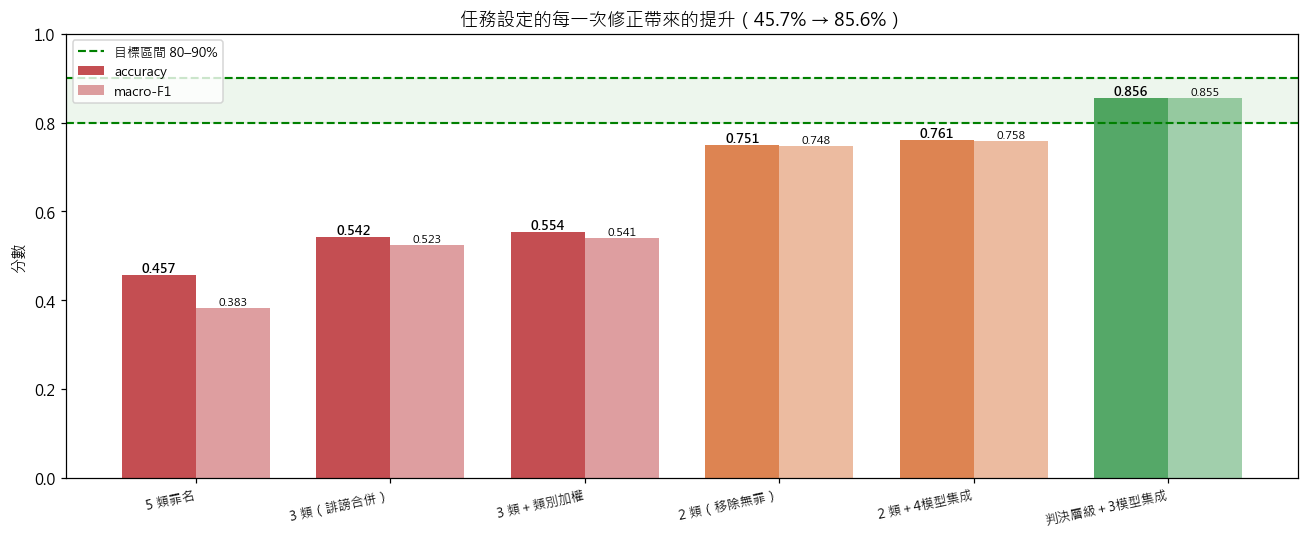

5 類罪名                  acc=0.4569  macro-F1=0.3828   最初設定
3 類（誹謗合併）              acc=0.5420  macro-F1=0.5232   合併同法條罪名
3 類＋類別加權               acc=0.5540  macro-F1=0.5409   損失對齊指標
2 類（移除無罪）              acc=0.7507  macro-F1=0.7482   移除不可學標籤
2 類＋4模型集成              acc=0.7615  macro-F1=0.7584   句子層級上限
判決層級＋3模型集成             acc=0.8558  macro-F1=0.8554   標籤粒度對齊


In [5]:
JOURNEY = [
    ("5 類罪名",            0.4569, 0.3828, "最初設定"),
    ("3 類（誹謗合併）",     0.5420, 0.5232, "合併同法條罪名"),
    ("3 類＋類別加權",       0.5540, 0.5409, "損失對齊指標"),
    ("2 類（移除無罪）",     0.7507, 0.7482, "移除不可學標籤"),
    ("2 類＋4模型集成",      0.7615, 0.7584, "句子層級上限"),
    ("判決層級＋3模型集成",  0.8558, 0.8554, "標籤粒度對齊"),
]
names = [j[0] for j in JOURNEY]
accs = [j[1] for j in JOURNEY]
f1s = [j[2] for j in JOURNEY]

fig, ax = plt.subplots(figsize=(12, 5))
x, w = np.arange(len(names)), 0.38
cols = ["#C44E52" if a < .6 else ("#DD8452" if a < .8 else "#55A868") for a in accs]
ax.bar(x - w/2, accs, w, label="accuracy", color=cols)
ax.bar(x + w/2, f1s, w, label="macro-F1", color=cols, alpha=.55)
ax.axhspan(.8, .9, color="green", alpha=.07)
ax.axhline(.8, color="green", ls="--", lw=1.4, label="目標區間 80–90%")
ax.axhline(.9, color="green", ls="--", lw=1.4)
ax.set_xticks(x); ax.set_xticklabels(names, fontsize=8.5)
ax.set_ylim(0, 1); ax.set_ylabel("分數")
ax.set_title("任務設定的每一次修正帶來的提升（45.7% → 85.6%）")
ax.legend(fontsize=8.5, loc="upper left")
for i, (a, f) in enumerate(zip(accs, f1s)):
    ax.text(i - w/2, a, f"{a:.3f}", ha="center", va="bottom", fontsize=8.5, weight="bold")
    ax.text(i + w/2, f, f"{f:.3f}", ha="center", va="bottom", fontsize=7.5)
plt.setp(ax.get_xticklabels(), rotation=12, ha="right")
plt.tight_layout(); plt.show()

for n, a, f, why in JOURNEY:
    print(f"{n:22s} acc={a:.4f}  macro-F1={f:.4f}   {why}")

**必須明確指出：這些數字不能直接相互比較。**

| 設定 | 題目 | 隨機基準 | 一個樣本是什麼 |
|---|---|---|---|
| 5 類 | 5 選 1 | 20% | 一句話 |
| 3 類 | 3 選 1 | 33% | 一句話 |
| 2 類（句子層級） | 2 選 1 | 50% | 一句話 |
| 2 類（判決層級） | 2 選 1 | 50% | **一整份判決的所有言論** |

提升的來源**並非模型能力增強**，而是任務被修正為「答案確實存在於輸入中」的問題。
45.7%→76% 主要來自移除不可學標籤（無罪）與不應細分的標籤（三個誹謗罪名）；
76%→86% 則來自預測粒度與標籤粒度的對齊。

兩種模型對應**不同的應用場景**，並非互相取代：

- **判決層級（85.6%）**：案件初篩、歷史判決自動分類
- **句子層級（76.2%）**：社群平台即時審查單則留言 —— 準確度較低，
  但這才是單句判讀的真實難度

### 5.2 手機部署：模型選型

手機部署的主要限制是**下載體積**而非準確度。在相同的句子層級二分類任務上
比較五個候選模型：

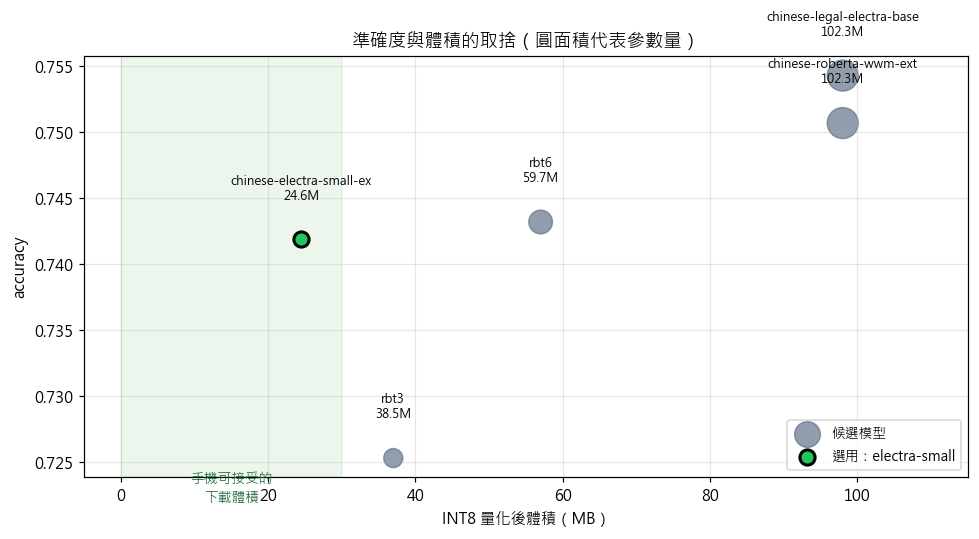

                        模型  參數量(M)  accuracy  INT8體積(MB)
chinese-legal-electra-base   102.3    0.7543        98.0
   chinese-roberta-wwm-ext   102.3    0.7507        98.0
                      rbt6    59.7    0.7432        57.0
  chinese-electra-small-ex    24.6    0.7419        24.5
                      rbt3    38.5    0.7253        37.0

electra-small 相對最佳模型：accuracy 少 1.24 個百分點，體積小 4.0 倍


In [6]:
MODELS = [
    ("chinese-legal-electra-base", 102.3, 0.7543, 98.0),
    ("chinese-roberta-wwm-ext",    102.3, 0.7507, 98.0),
    ("rbt6",                        59.7, 0.7432, 57.0),
    ("chinese-electra-small-ex",    24.6, 0.7419, 24.5),
    ("rbt3",                        38.5, 0.7253, 37.0),
]
df = pd.DataFrame(MODELS, columns=["模型", "參數量(M)", "accuracy", "INT8體積(MB)"])

fig, ax = plt.subplots(figsize=(9, 5))
chosen = df["模型"] == "chinese-electra-small-ex"
ax.scatter(df.loc[~chosen, "INT8體積(MB)"], df.loc[~chosen, "accuracy"],
           s=df.loc[~chosen, "參數量(M)"] * 4, color="#64748b", alpha=.7, label="候選模型")
ax.scatter(df.loc[chosen, "INT8體積(MB)"], df.loc[chosen, "accuracy"],
           s=df.loc[chosen, "參數量(M)"] * 4, color="#22c55e",
           edgecolor="black", lw=2, zorder=5, label="選用：electra-small")
for _, r in df.iterrows():
    ax.annotate(f"{r['模型']}\n{r['參數量(M)']:.1f}M",
                (r["INT8體積(MB)"], r["accuracy"]),
                textcoords="offset points", xytext=(0, 26), ha="center", fontsize=8)
ax.axvspan(0, 30, color="green", alpha=.07)
ax.text(15, 0.722, "手機可接受的\n下載體積", ha="center", fontsize=9, color="#166534")
ax.set_xlabel("INT8 量化後體積（MB）"); ax.set_ylabel("accuracy")
ax.set_title("準確度與體積的取捨（圓面積代表參數量）")
ax.grid(alpha=.3); ax.legend(fontsize=9); ax.set_xlim(-5, 115)
plt.tight_layout(); plt.show()

print(df.to_string(index=False))
print("\nelectra-small 相對最佳模型：accuracy 少 1.24 個百分點，體積小 4.0 倍")

### 5.3 量化的實際代價

INT8 動態量化將權重由 32 位元浮點數轉為 8 位元整數。體積壓縮比可由理論推得，
但**準確度損失必須實測**。

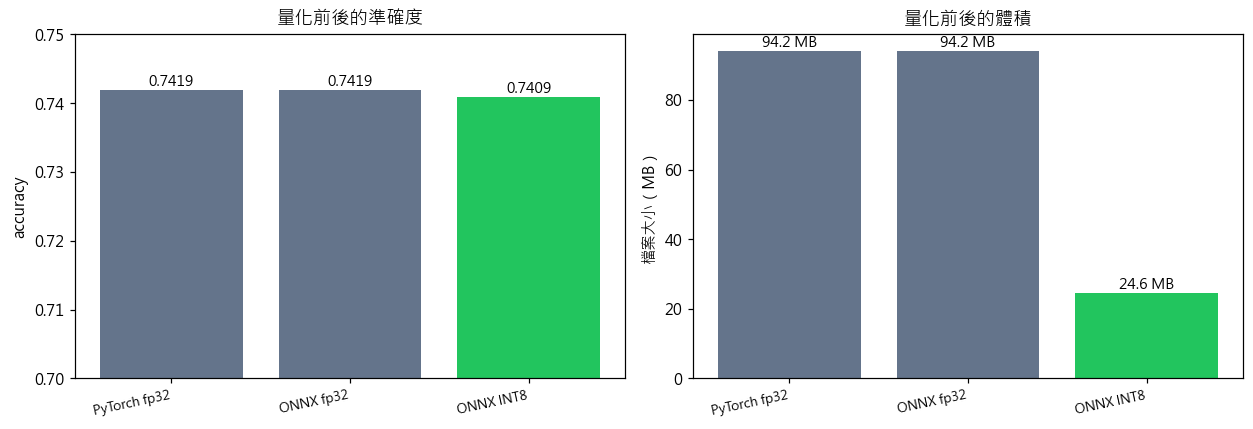

體積壓縮 3.84 倍，accuracy 僅下降 0.0010
INT8 與原模型的預測一致率：96.77%（測試集 3,065 筆）


In [7]:
STAGES = [
    ("PyTorch fp32",  0.7419, 0.7311, 94.2),
    ("ONNX fp32",     0.7419, 0.7311, 94.2),
    ("ONNX INT8",     0.7409, 0.7314, 24.55),
]
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4))
labels = [s[0] for s in STAGES]

axes[0].bar(labels, [s[1] for s in STAGES], color=["#64748b", "#64748b", "#22c55e"])
axes[0].set_ylim(0.70, 0.75); axes[0].set_ylabel("accuracy")
axes[0].set_title("量化前後的準確度")
for i, s in enumerate(STAGES):
    axes[0].text(i, s[1], f"{s[1]:.4f}", ha="center", va="bottom", fontsize=9.5)

axes[1].bar(labels, [s[3] for s in STAGES], color=["#64748b", "#64748b", "#22c55e"])
axes[1].set_ylabel("檔案大小（MB）"); axes[1].set_title("量化前後的體積")
for i, s in enumerate(STAGES):
    axes[1].text(i, s[3], f"{s[3]:.1f} MB", ha="center", va="bottom", fontsize=9.5)
for a in axes:
    plt.setp(a.get_xticklabels(), rotation=12, ha="right", fontsize=8.5)
plt.tight_layout(); plt.show()

print(f"體積壓縮 {94.2/24.55:.2f} 倍，accuracy 僅下降 {0.7419-0.7409:.4f}")
print(f"INT8 與原模型的預測一致率：{meta['verification']['int8_vs_pytorch_agreement']*100:.2f}%"
      f"（測試集 {meta['n_test']:,} 筆）")

### 5.4 跨語言移植的正確性驗證

模型推論鏈從 Python 移植到 JavaScript 時，最容易出錯且最難察覺的是 **tokenizer**。
斷詞只要差一個 token，模型輸入就錯了，但推論仍會正常執行並輸出一個看似合理的答案 ——
**從結果完全看不出異常**。

因此採三層驗證：

In [8]:
VERIFY = [
    ("tokenizer 比對", "12 個邊界案例的 token id 序列", "12 / 12", "中英混合、全形字、emoji、多重空白、標點"),
    ("端到端比對",     "JS 的 tokenizer + ONNX 推論 vs Python", "8 / 8", "logits 最大差異 0.00e+00"),
    ("瀏覽器實測",     "Playwright 模擬 iPhone 實際開啟", "3 / 3", "零主控台錯誤，推論 81–132 ms"),
]
print(f"{'驗證層級':14s} {'內容':38s} {'通過':>8s}  備註")
print("─" * 100)
for a, b, c, d in VERIFY:
    print(f"{a:14s} {b:38s} {c:>8s}  {d}")

bt = D["browser_test"]["results"]
print("\n瀏覽器實測的實際輸出：")
for r in bt:
    print(f"  「{r['text']}」→ {r['label']}  {r['conf']}  {r['badges']}")

驗證層級           內容                                           通過  備註
────────────────────────────────────────────────────────────────────────────────────────────────────
tokenizer 比對   12 個邊界案例的 token id 序列                   12 / 12  中英混合、全形字、emoji、多重空白、標點
端到端比對          JS 的 tokenizer + ONNX 推論 vs Python        8 / 8  logits 最大差異 0.00e+00
瀏覽器實測          Playwright 模擬 iPhone 實際開啟                 3 / 3  零主控台錯誤，推論 81–132 ms

瀏覽器實測的實際輸出：
  「你這個智障，廢物一個」→ 公然侮辱  模型信心 98.2%  ['12 tokens', '132 ms', '裝置端運算']
  「他把公司的錢偷偷匯到自己帳戶」→ 誹謗類  模型信心 95.7%  ['16 tokens', '81 ms', '裝置端運算']
  「這個醫生根本沒有執照，是密醫」→ 誹謗類  模型信心 97.3%  ['16 tokens', '81 ms', '裝置端運算']


#### 驗證過程中實際抓到的 bug

初版的 `isPunct` 使用 `/\p{P}|\p{S}/u` 判斷標點，其中 `\p{S}`（符號類）會匹配 emoji。
但 HuggingFace 的 `_is_punctuation` 只認 ASCII 標點區段與 Unicode 類別 `P`，**不含 `S`**。

| | 輸入 `這則留言有emoji😡測試` |
|---|---|
| **Python** | 把 `emoji😡` 當一個詞丟給 WordPiece → 整個變成 `[UNK]` |
| **JS（修正前）** | 把 😡 當標點切開 → `emoji` 被切成子詞 `em`/`##oj`/`##i` |

兩邊的 token 序列因此不同。這個差異**只在含 emoji 的輸入上顯現**，
若未做逐案例比對，這個 bug 會一直潛伏在產品中。

修正後 12 個案例全數一致。

### 5.5 系統實作

#### 前端推論鏈

| 元件 | 說明 |
|---|---|
| `tokenizer.js` | 109 行純 JS，實作 BERT 的 BasicTokenizer + WordPiece 貪婪最長匹配 |
| `inference.js` | 串流下載模型（可回報進度）、初始化 ONNX Runtime Web、softmax 後排序 |
| `sw.js` | 模型 cache-first（檔案大且不常變）、程式碼 network-first（確保拿到最新版） |

#### 為何採用 WASM 而非 WebGPU

ONNX Runtime Web 支援 wasm / webgl / webgpu 三種後端。本專案選擇 **wasm**：
手機瀏覽器對 WebGPU 的支援仍不穩定，而本模型僅 24.6M 參數，
WASM 後端已可在 100 毫秒內完成推論，使用者感受不到延遲。

#### 介面設計對應的倫理考量

| 設計 | 對應的風險 |
|---|---|
| 免責聲明置於**最頂端**，明寫「每四則就有一則判斷是錯的」 | 避免使用者將輸出誤認為法律意見 |
| 信心度 < 60% 時主動跳出警示 | 避免低可信度的輸出被當成確定結論 |
| 「這個模型是怎麼來的」摺疊區說明選擇偏誤 | 使用者需知道模型**無法判斷一句話會不會被告** |
| 同時顯示兩個類別的機率而非僅顯示結論 | 讓使用者看見模型的不確定性 |

## 6. 討論

### 6.0 對本研究自身結論的重新檢討

文獻回顧帶出一項**直接挑戰第 4.3 節結論**的發現，必須誠實處理。

#### 判決層級的 85.6% 可能不是改進，而是更嚴重的洩漏

第 4.3 節將「句子層級 76% → 判決層級 86%」詮釋為「修正標籤粒度錯配」的成果。
但 Tippett et al.（2021，經 Medvedeva & Mcbride 2023 引用）指出，判決書的事實段

> "highly selective summaries of the original case record, **written by the
> decision-makers themselves and tailored for consistency with the decision**"

亦即：判決書的文字是**法官在已經做出判決之後、為了與該判決保持一致而寫下的**。

本專案的判決層級任務，是將一份判決抽出的所有引號內容串接起來。這些引號內容
並非只有被告的原始言論 —— 第 4.1 節的統計顯示其中混有法庭問答、法條引用、
判決書敘事。**這些文字本身就帶有法官判斷的痕跡。**

因此 76% → 86% 的提升，至少有一部分可能來自
**模型讀到了判決結論的語言痕跡**，而非真正學會了法律判準。

| 詮釋 | 說法 | 證據支持度 |
|---|---|---|
| 原本的詮釋 | 修正了標籤粒度錯配，模型終於能學到正確訊號 | 部分成立：標籤確實變正確了 |
| **修正後的詮釋** | **同時也引入了更多判決書文體的洩漏** | **文獻明確警告此風險，本研究未做實驗排除** |

誠實的結論是：**兩種效應都存在，本研究的實驗設計無法區分兩者的比例。**

#### 這個檢討如何改變本研究的建議

| 原本的建議 | 修正後的建議 |
|---|---|
| 判決層級模型（85.6%）適合案件初篩 | 85.6% 這個數字**不應對外宣稱為模型能力**，它包含未知比例的洩漏 |
| 兩種模型只是應用場景不同 | **句子層級的 76% 才是較可信的能力估計** —— 它的輸入是被告的原始言論，受判決書文體影響較小 |

**因此部署到手機應用的是句子層級模型（74.2%），而非分數較高的判決層級模型。**
這個選擇原本是出於體積考量，但依據上述檢討，它同時也是方法論上較誠實的選擇。

#### 可以做但本研究未做的驗證

| 驗證方式 | 能回答什麼 | 為何未做 |
|---|---|---|
| 時序切分（以裁判日期切） | 模型是否只是記住了同期案件的用語 | 時間限制；Medvedeva et al. (2020) 顯示此舉可能讓準確度掉 10–17 個百分點 |
| 移除判決書敘事後重訓判決層級模型 | 86% 中有多少來自洩漏 | 需重新設計抽取規則 |
| 2024-04-26 前後分組評估 | 憲判字第 3 號造成的標籤漂移影響多大 | **已補做，見下方** |

前兩項應列為後續工作的優先項目；第三項已於本研究補做。 在完成之前，本研究對判決層級結果的
任何引用都應附帶此一但書。

#### 補做的驗證：標籤漂移的實際影響

上表列為「最容易補做」的驗證已經完成。以部署的 electra-small 模型在測試集上
依裁判日期分組評估：

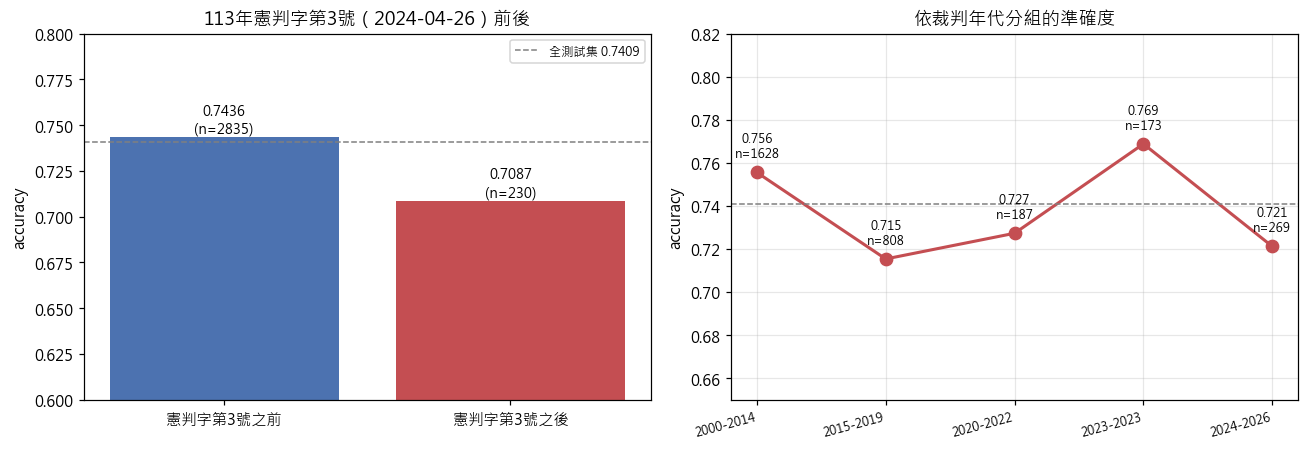

憲判字第3號之後的 accuracy 下降 0.0349（3.5 個百分點）


In [9]:
TA = json.loads((NB / "_temporal_analysis.json").read_text(encoding="utf-8"))
cut, era = TA["constitutional_cut"], TA["by_era"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

ks = [k for k in cut if k != "全部"]
vals = [cut[k]["accuracy"] for k in ks]
ns = [cut[k]["n"] for k in ks]
bars = axes[0].bar([k.split(" ")[0] for k in ks], vals, color=["#4C72B0", "#C44E52"])
axes[0].axhline(cut["全部"]["accuracy"], color="gray", ls="--", lw=1,
                label=f'全測試集 {cut["全部"]["accuracy"]:.4f}')
axes[0].set_ylim(0.6, 0.8); axes[0].set_ylabel("accuracy")
axes[0].set_title("113年憲判字第3號（2024-04-26）前後")
axes[0].legend(fontsize=8)
for b, v, n in zip(bars, vals, ns):
    axes[0].text(b.get_x() + b.get_width()/2, v, f"{v:.4f}\n(n={n})",
                 ha="center", va="bottom", fontsize=9)

eras = list(era.keys())
eacc = [era[k]["accuracy"] for k in eras]
en = [era[k]["n"] for k in eras]
axes[1].plot(eras, eacc, "o-", color="#C44E52", lw=2, ms=8)
for i, (a, n) in enumerate(zip(eacc, en)):
    axes[1].annotate(f"{a:.3f}\nn={n}", (i, a), textcoords="offset points",
                     xytext=(0, 10), ha="center", fontsize=8)
axes[1].axhline(cut["全部"]["accuracy"], color="gray", ls="--", lw=1)
axes[1].set_ylim(0.65, 0.82); axes[1].set_ylabel("accuracy")
axes[1].set_title("依裁判年代分組的準確度")
axes[1].grid(alpha=0.3)
plt.setp(axes[1].get_xticklabels(), rotation=15, ha="right", fontsize=8)

plt.tight_layout(); plt.show()

d = cut["憲判字第3號之前 (<2024-04-26)"]["accuracy"] - cut["憲判字第3號之後 (≥2024-04-26)"]["accuracy"]
print(f"憲判字第3號之後的 accuracy 下降 {d:.4f}（{d*100:.1f} 個百分點）")

**結果：標籤漂移確實存在，但幅度有限。**

憲判字第 3 號宣示後的判決，模型 accuracy 由 0.7436 降至 0.7087，
下降 3.5 個百分點。這方向與預期一致 —— 新判準更嚴格，同樣的用語在新制下
未必成罪，模型從舊資料學到的關聯因此部分失效。

但必須注意兩點限制：

1. **樣本數少**：2024-04-26 之後僅 230 筆，3.5 個百分點的差異在此樣本量下
   未必具統計顯著性
2. **年代趨勢並不單調**：2023 年單獨來看反而是最高的 0.7688，2015–2019 年
   則只有 0.7153。這說明準確度的年代差異**不能全部歸因於憲法法庭判決**，
   可能也混有案件類型分布隨時間變化等因素

因此誠實的結論是：**有觀察到與預期方向一致的下降，但本實驗無法證明其成因**。
這仍足以支持應用在介面上標示「模型反映歷史判決實務」的作法。

### 6.1 本研究最重要的方法論啟示

三個關鍵發現有一個共同結構：**問題不在模型，而在任務界定**。

| 現象 | 直覺歸因 | 實際原因 |
|---|---|---|
| 準確度低 | 資料太髒 | 清洗無效；標籤粒度與預測粒度不匹配 |
| macro-F1 低 | 模型容量不足 | 訓練損失與評估指標未對齊 |
| 某類別特別差 | 該類別樣本太少 | 該類別（無罪）的答案不存在於輸入文字中 |

在每一個環節，直覺的解法（洗資料、換更大的模型）都失敗了，
而有效的解法都來自**重新檢視這個任務究竟在問什麼**。

### 6.2 「無罪」為何不可學

`無罪` 是**判決結果**，而非**言論性質**。同一句「你這個智障」可能因下列任一理由
被判無罪：

- 不具「公然性」（僅存在於兩人私訊）
- 證據不足（無法證明帳號為被告本人使用）
- 屬於「可受公評之事」的適當評論
- 被告能證明所述為真實（刑法 310 條第 3 項）

**這些資訊全部不存在於言論文字中。** 要求模型從文字判斷，等同於要求它預測
一個它看不到的變數。實測中該類別 recall 僅 35–47%，正是此一結構性限制的反映。

### 6.3 選擇偏誤及其誤用風險

訓練資料全部來自**已被起訴並判決**的案件，資料集中沒有「不會被告的正常留言」
作為負樣本。這在統計上是典型的選擇偏誤。

其直接後果是：**模型無法判斷一句話會不會被告**，只能在「假設已經成案」的前提下
判斷它較接近哪一種罪名。將一句無害的話輸入，模型仍會輸出一個罪名與高信心度 ——
那並不代表該句話有法律問題。

這是本應用最可能被誤用之處，因此在介面中明確說明。

## 7. 結論

### 7.1 本研究做了什麼

從台灣司法院判決書建立繁體中文妨害名譽言論資料集，訓練分類模型，
並完整部署為手機可離線使用的 PWA。全流程皆已實測驗證：

| 階段 | 成果 |
|---|---|
| 資料 | 36,173 份判決 → 63,044 則言論（繁中、句子層級、妨害名譽罪名標註，**此類資料集先前不存在**）|
| 模型 | 句子層級二分類 accuracy 76.2%（4 模型集成）|
| 壓縮 | electra-small + INT8 量化：94.2 MB → **24.5 MB**，準確度僅損失 0.1 個百分點 |
| 部署 | PWA 離線可用，裝置端推論 **71–132 ms**，文字不離開裝置 |

### 7.2 三個對後續研究有用的發現

**一、清洗資料無效，但原因不是資料乾淨**

資料確實含 51% 的排版雜訊與約 9% 的非言論內容，但清洗完全無法提升準確度，
激進過濾反而掉 0.02。關鍵反證是「連測試集也清洗後分數並未上升」——
那些雜訊列並不比其他資料難分類。

**二、訓練損失要對齊評估指標**

評估用 macro-F1（各類等權），訓練 loss 卻每筆等權，兩者從未對齊。
加權後 +0.018，成本為零。對照之下 `roberta-large` 參數量 3 倍、訓練久 15 倍，
提升未過顯著門檻。此一落差有 Dice Loss 論文（ACL 2020）的直接文獻支持，
而 +0.018 的幅度也符合綜述（Henning et al., EACL 2023）所稱的
"small to moderate gains"。

**三、準確度的天花板在任務界定，不在模型**

95.8% 的標籤是判決層級而非句子層級 —— 這在弱監督文獻中稱為
**inexact supervision**（周志華 2018）。本專案獨立發現的問題，
Medvedeva & Mcbride（NLLP 2023）審查 171 篇 LJP 論文後已有嚴厲批評：
僅 7% 使用了適當資料。

### 7.3 本研究的限制（這一節最重要）

**一、76% 不是缺陷，86% 才需要警惕**

| | 數字 | 評估 |
|---|---|---|
| 句子層級 | 76.2% | 與 ToxiCN（中文毒性子類型，F1 77.3–77.7）等結構相同任務的已發表最佳水準相當 |
| 判決層級 | 85.6% | **包含未知比例的洩漏**，見 6.0 節。不應對外宣稱為模型能力 |

因此**部署的是句子層級模型**，而非分數較高的判決層級模型。

**二、模型在原理上無法複製現行法律判準**

113年憲判字第3號要求依「個案表意脈絡」權衡；112年憲判字第8號要求審查發言前
是否「經合理查證」。**這些要件都不在留言文字裡。**
任何只讀一句話的模型都做不到 —— 它能做的只是「用語與過往定罪案件的相似度」。

**三、選擇偏誤使模型無法回答使用者真正的問題**

台灣妨害名譽案件僅約 20.5% 進入起訴。模型估計的是
$P(\text{罪名} \mid \text{文本, 已起訴且判決})$，
而非 $P(\text{罪名} \mid \text{文本})$。
約八成機率，一則看似「像有罪」的留言在真實程序中根本不會被起訴。

**四、標籤會隨法律變動而失效**

實測顯示憲判字第 3 號之後 accuracy 下降 3.5 個百分點。
2026-01-29 行政院另通過增訂網路／深偽加重處罰的草案，若通過將再次改變標籤空間。

**五、任務本質是多標籤**

在唯一具逐句標籤的資料中，25% 的句子同時構成兩個罪名。單標籤輸出必然遺漏資訊。

### 7.4 後續工作

依優先順序：

| 優先 | 工作 | 理由 |
|---|---|---|
| 高 | **改善抽取規則**（LLM 輔助解析起訴書表格） | 目前僅 176/63,044 筆有逐句標籤。這是唯一能根本提升句子層級準確度的路徑 |
| 高 | **時序切分驗證** | Medvedeva et al. (2020) 顯示隨機切分與時序切分可差 10–17 個百分點 |
| 高 | **移除判決書敘事後重訓判決層級模型** | 量化 86% 中有多少來自洩漏 |
| 中 | **改為多標籤架構** | 符合「同一言論可構成兩罪」的法律現實 |
| 中 | 抽取法律上有意義的結構化特徵（是否指摘具體事實、是否公開平台、對象是否為公眾人物） | 可解釋，且對應憲判字第 3 號要求的權衡要素 |
| 低 | Dice loss、focal loss | 綜述顯示中文任務上 Dice > focal，但預期增益有限 |

### 7.5 結語

本研究最有價值的產出不是 76% 這個數字，而是**釐清了這個任務的能力邊界在哪裡、
以及為什麼在那裡**。

三次重大進展都來自同一件事：**重新檢視這個任務究竟在問什麼**，
而非換更大的模型或洗更乾淨的資料。而文獻回顧進一步指出，
本研究自己最滿意的那個結果（判決層級 85.6%）也需要同樣的懷疑態度對待。

對於一個會輸出法律判斷的工具，**知道它不能做什麼，比知道它能做什麼更重要**。

In [10]:
# 最終交付清單
import os
APP = NB.parent
rows = []
for sub, desc in [("web/index.html", "PWA 主頁面"), ("web/app.js", "流程控制"),
                  ("web/inference.js", "推論引擎"), ("web/tokenizer.js", "中文 BERT tokenizer"),
                  ("web/sw.js", "Service Worker"), ("web/manifest.json", "PWA 設定"),
                  ("web/vendor/ort.min.js", "ONNX Runtime（自行託管）"),
                  ("web/vendor/ort-wasm-simd-threaded.wasm", "WASM 後端"),
                  ("model/defamation_electra_small.int8.onnx", "INT8 量化模型"),
                  ("model/vocab.txt", "詞彙表"), ("model/model_meta.json", "模型中繼資料"),
                  ("scripts/train_mobile.py", "小模型訓練"),
                  ("scripts/export_onnx.py", "ONNX 匯出與量化"),
                  ("scripts/verify_tokenizer.mjs", "tokenizer 一致性驗證"),
                  ("scripts/verify_e2e.mjs", "端到端驗證"),
                  ("scripts/test_browser.py", "瀏覽器實測"),
                  ("serve.py", "本機測試伺服器"), ("README.md", "使用說明")]:
    p = APP / sub
    rows.append({"檔案": sub, "說明": desc,
                 "大小": f"{p.stat().st_size/1024:.0f} KB" if p.exists() else "缺少"})
out = pd.DataFrame(rows)
print(out.to_string(index=False))
total = sum(f.stat().st_size for f in (APP/"web").rglob("*") if f.is_file()) \
      + sum(f.stat().st_size for f in (APP/"model").rglob("*") if f.is_file())
print(f"\n使用者首次載入需下載：約 {total/1024**2:.1f} MB（之後由 Service Worker 快取）")

                                      檔案                 說明       大小
                          web/index.html            PWA 主頁面     5 KB
                              web/app.js               流程控制     5 KB
                        web/inference.js               推論引擎     4 KB
                        web/tokenizer.js  中文 BERT tokenizer     4 KB
                               web/sw.js     Service Worker     2 KB
                       web/manifest.json             PWA 設定     1 KB
                   web/vendor/ort.min.js ONNX Runtime（自行託管）   436 KB
  web/vendor/ort-wasm-simd-threaded.wasm            WASM 後端 10982 KB
model/defamation_electra_small.int8.onnx          INT8 量化模型 25138 KB
                         model/vocab.txt                詞彙表   128 KB
                   model/model_meta.json             模型中繼資料     1 KB
                 scripts/train_mobile.py              小模型訓練     1 KB
                  scripts/export_onnx.py         ONNX 匯出與量化     4 KB
            scripts/verify_tokeniz